In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dữ liệu luồng mạng từ thư mục data
df = pd.read_csv('../data/processed/ctu13_labeled_flows.csv')

print(f"Kích thước tập dữ liệu: {df.shape}")
df.head()

Kích thước tập dữ liệu: (104385, 16)


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,total_fwd_pkts,total_bwd_pkts,total_fwd_bytes,total_bwd_bytes,bytes_per_sec,packets_per_sec,packet_len_mean,packet_len_std,label
0,147.32.84.59,213.239.192.34,7525,50012,17,1.313495e+09,1277.465040,1203,403,50526,16926,52.801445,1.257177,42.0,0.0,0
1,147.32.84.59,188.40.100.105,7525,50012,17,1.313495e+09,1200.943712,616,624,25872,26208,43.365896,1.032521,42.0,0.0,0
2,147.32.84.229,80.98.130.52,13363,51686,6,1.313495e+09,1276.750577,55,57,2970,3078,4.737025,0.087723,54.0,0.0,0
3,147.32.84.59,78.46.38.219,7525,55012,17,1.313495e+09,1190.095161,1392,449,58464,18858,64.971275,1.546935,42.0,0.0,0
4,147.32.84.59,213.239.199.195,7525,51012,17,1.313495e+09,1257.621137,1296,594,54432,24948,63.119168,1.502837,42.0,0.0,0


In [4]:
# Kiểm tra số lượng giá trịa NaN trên từng cột
print("Số lượng giá trị NaN mỗi cột:")
print(df.isnull().sum())

# Kiểm tra số lượng giá trị Inf (vô cùng)
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print("\nSố lượng giá trị Inf mỗi cột:")
print(inf_count[inf_count > 0])

Số lượng giá trị NaN mỗi cột:
src_ip             0
dst_ip             0
src_port           0
dst_port           0
protocol           0
timestamp          0
flow_duration      0
total_fwd_pkts     0
total_bwd_pkts     0
total_fwd_bytes    0
total_bwd_bytes    0
bytes_per_sec      0
packets_per_sec    0
packet_len_mean    0
packet_len_std     0
label              0
dtype: int64

Số lượng giá trị Inf mỗi cột:
Series([], dtype: int64)


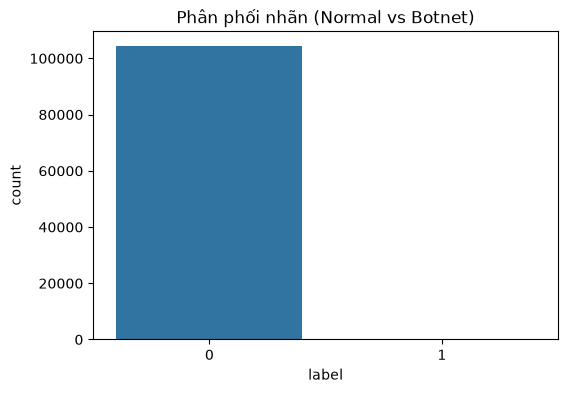

Tỷ lệ phần trăm các nhãn:
label
0    99.954016
1     0.045984
Name: proportion, dtype: float64


In [5]:
# Trực quan hóa tỷ lệ mất cân bằng nhãn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Phân phối nhãn (Normal vs Botnet)')
plt.show()

print("Tỷ lệ phần trăm các nhãn:")
print(df['label'].value_counts(normalize=True) * 100)

In [7]:
from pathlib import Path
import sys

# Thêm thư mục gốc của project để import package src
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.features.preprocessor import NetworkPreprocessor
import pandas as pd

# 1. Khởi tạo preprocessor
preprocessor = NetworkPreprocessor()

# 2. Chạy pipeline xử lý (loại bỏ anti-leakage, xử lý đặc trưng)
X, y = preprocessor.preprocess_pipeline(df, target_col='label')

# 3. Chia tập train/test và chuẩn hóa RobustScaler
X_train, X_test, y_train, y_test = preprocessor.split_and_scale(X, y)

# 4. Lưu lại thành file để bàn giao cho Dev 4
train_df = pd.DataFrame(X_train)
train_df['label'] = y_train.values

test_df = pd.DataFrame(X_test)
test_df['label'] = y_test.values

train_df.to_csv('../data/train_processed.csv', index=False)
test_df.to_csv('../data/test_processed.csv', index=False)

print("Đã xử lý và xuất file train/test sạch sẽ cho Dev 4 thành công!")

ModuleNotFoundError: No module named 'sklearn'